First five lines of dataset
   student_id  weekly_self_study_hours  attendance_percentage  \
0           1                     18.5                   95.6   
1           2                     14.0                   80.0   
2           3                     19.5                   86.3   
3           4                     25.7                   70.2   
4           5                     13.4                   81.9   

   class_participation  total_score grade  
0                  3.8         97.9     A  
1                  2.5         83.9     B  
2                  5.3        100.0     A  
3                  7.0        100.0     A  
4                  6.9         92.0     A  
Last five lines of dataset
        student_id  weekly_self_study_hours  attendance_percentage  \
999995      999996                     18.0                   95.5   
999996      999997                     15.7                   82.7   
999997      999998                     14.2                   85.1   
999998    

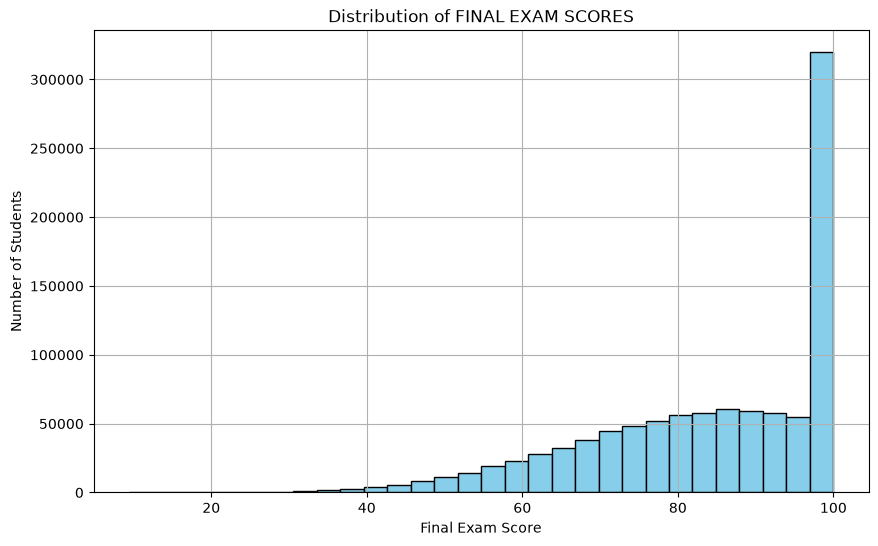

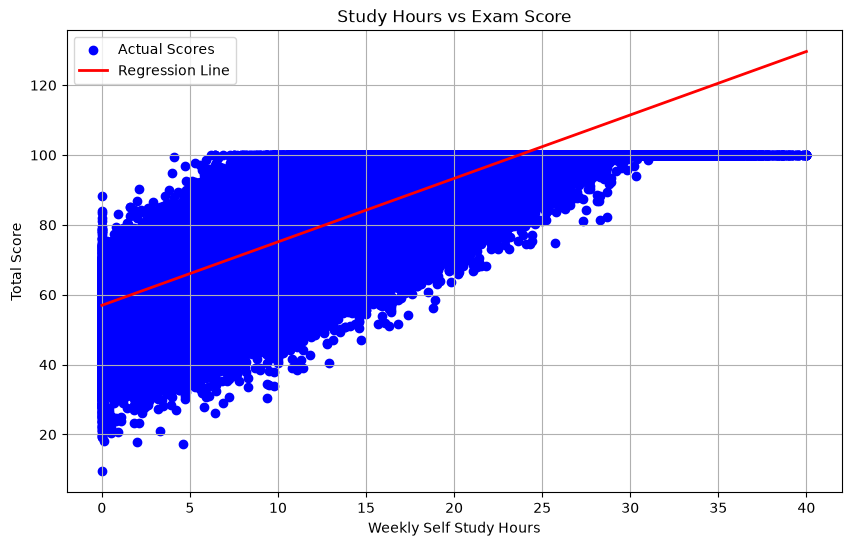

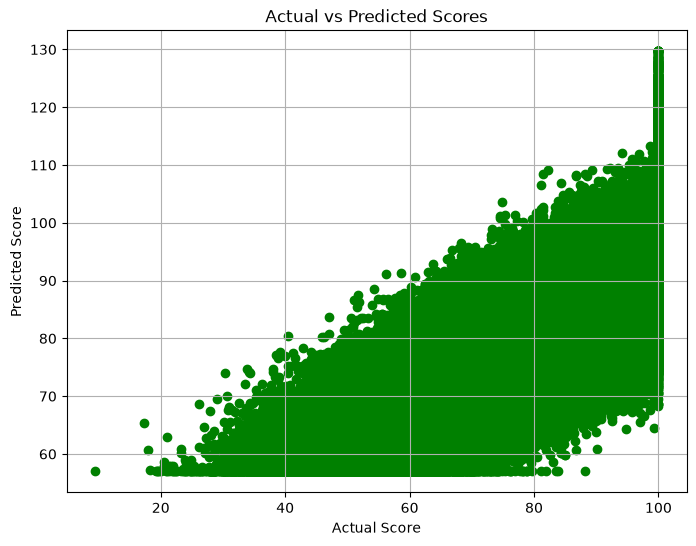

Predicted Score: 98.76


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

##load data
data = pd.read_csv("student_performance.csv")

##Exploratory Data Analysis (EDA)
print("First five lines of dataset")
print(data.head())
print("Last five lines of dataset")
print(data.tail())


print(data.info())

print(data.describe())

print(data.isnull().sum())
#There are 0 missing values in dataset

print(data.duplicated().sum())
data.drop_duplicates(inplace=True)

# input & Output

X = data[["weekly_self_study_hours"]]
y = data["total_score"]

#train model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)



predicted_scores = model.predict(X_test)


#valid regression metrics
mae = mean_absolute_error(y_test, predicted_scores)
mse = mean_squared_error(y_test, predicted_scores)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predicted_scores)

#show result

print("Mean absolute ERROR (mae): ", round(mae, 2))
print("Mean squared ERROR (mse): ", round(mse, 2))
print("Root Mean Squared ERROR (rmse): ", round(rmse, 2))
print("R^2 Score (Model Accuracy): ", round(r2, 2))# closer ti 1 = better

#histogram
plt.figure(figsize=(10, 6))
plt.hist(data["total_score"], bins = 30, color = 'skyblue', edgecolor='black')
plt.title("Distribution of FINAL EXAM SCORES")
plt.xlabel("Final Exam Score")
plt.ylabel("Number of Students")
plt.grid(True)
plt.show()

#Scatter + regression line
sorted_index = X_test["weekly_self_study_hours"].argsort()

X_test_sorted = X_test.iloc[sorted_index]
y_pred_sorted = predicted_scores[sorted_index]

plt.figure(figsize=(10,6))

plt.scatter(X_test, y_test, color="blue", label="Actual Scores")

plt.plot(X_test_sorted, y_pred_sorted, color="red", linewidth=2, label="Regression Line")

plt.xlabel("Weekly Self Study Hours")
plt.ylabel("Total Score")
plt.title("Study Hours vs Exam Score")
plt.legend()
plt.grid(True)
plt.show()

#ACtual vs Predicted Plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, predicted_scores, color="green")
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Scores")
plt.grid(True)
plt.show()


new_data = pd.DataFrame({"weekly_self_study_hours": [23]})
new_pred = model.predict(new_data)
print("Predicted Score:", round(new_pred[0], 2))